### **We use the landsat578-based prtrained model (pytorch-based) for surface water mapping**


In [50]:
import torch
import numpy as np
import rasterio as rio
import sys
sys.path.append('..')
from utils.imgPatch import imgPatch
from model.model.unet import unet
from utils.imgShow import imsShow


In [51]:
import sys
sys.path.append('..')
path_img = '../data/scene/S2_2025_1_0.tif'   ## path to input image
path_wat_pred = '../data/result/S2_2025_1_0_pred.tif'   ## path to save result
path_trained_model = '../model/trained/unet_s2_without.pth'


In [52]:
## load trained model
model = unet(num_bands=6)
model.eval()
model.load_state_dict(torch.load(path_trained_model, weights_only=True))


<All keys matched successfully>

In [53]:
### surface water mapping by using trained model
print('image:', path_img)
### --- 1. read in satellite images 
with rio.open(path_img) as src:
    img = src.read().transpose(1, 2, 0)  # change to channel last format
    img_meta = src.meta # obtain metadata for writing result
img = np.float32(np.clip(img/1, a_min=0, a_max=1))     ### normalization

### ---- 2. surface water mapping using trained model 
imgPat_ins = imgPatch(img=img, patch_size=512, edge_overlay = 64)
patch_list, start_list, img_patch_row, img_patch_col = imgPat_ins.toPatch()
patch_list = [torch.from_numpy(patch.transpose(2,0,1)) for patch in patch_list]  # 1.channel first and 2.numpy array to torch tensor
result_patch_list = [model(patch[np.newaxis, :]) for patch in patch_list]
result_patch_list = [np.squeeze(patch.detach().numpy().transpose(0,2,3,1), axis = 0) 
                                for patch in result_patch_list]       ## 1.channel last and 2.torch tensor to numpy array
pro_pred = imgPat_ins.toImage(result_patch_list, img_patch_row, img_patch_col)
cla_pred = np.where(pro_pred>0.7, 1, 0).squeeze()
cla_pred = np.int8(cla_pred)

image: ../data/scene/S2_2025_1_0.tif


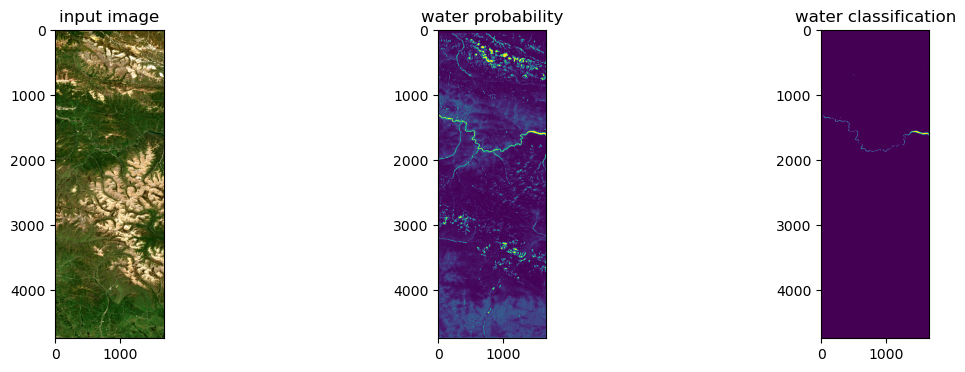

In [54]:
### show the results
imsShow([img, pro_pred, cla_pred],
         ['input image', 'water probability', 'water classification'],
         figsize=(14, 4))


In [55]:
### write the result to path
with rio.open(path_wat_pred, 'w', driver='GTiff',
             height=cla_pred.shape[0],
             width=cla_pred.shape[1],
             count=1,
             dtype=np.int8,
             crs=img_meta['crs'],
             transform=img_meta['transform']) as dst:
    dst.write(cla_pred, 1)  


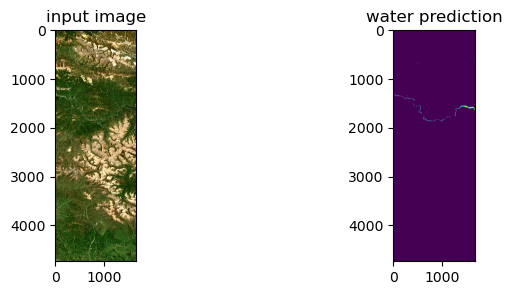

In [56]:
## load and show the image and the prediction map
with rio.open(path_img) as img_src, rio.open(path_wat_pred) as pred_src:
    img_arr = img_src.read().transpose(1, 2, 0)  # change to channel last format
    pred_arr = pred_src.read(1)   # read the first band (the classification result)
imsShow([img_arr, pred_arr], ['input image', 'water prediction'], figsize=(8, 3))
